In [1]:
#DATA LOADING
import pandas as pd
import numpy as np         
df= pd.read_csv("cleaned_Response.csv")
df.columns= df.columns.str.strip()
df.head()           #df= dataframe

,Timestamp,What's your gender?,What's your age?,What's your field of study?,What's your current academic year?,GPA in last semester,1. I do not do assignments until just before they are to be handed in.,"2. I continually say ""I'll do this task tomorrow"".",3. Procrastination on a task affects my scores of that task.,4. I procrastinate because the task is difficult for me.,5. Finishing academic tasks before last minutes of deadlines gives me a lot pressures.,6. I cannot control shifting attention to other more pleasurable activities when working on academic task.,7. I feel guilty about my procrastinations on academic tasks.,8. I am not motivated to do academic tasks.,9. I can receive better grade if I started earlier on academic tasks.,10. I am afraid of the consequences of procrastinating academic tasks.,GPA_numeric
0,4/16/2026 18:28:42,Female,21-23,Computer Science / IT,2nd Year,2.5–3.0,2,2,2,4,3,4,4,3,2,2,2.75
1,4/16/2026 18:30:14,Female,18-20,Computer Science / IT,2nd Year,3.5- 4.0,4,2,2,4,2,4,3,4,4,4,3.75
2,4/16/2026 18:35:21,Male,21-23,Computer Science / IT,2nd Year,2.5–3.0,3,2,2,4,1,2,5,1,5,5,2.75
3,4/16/2026 18:44:35,Female,21-23,Computer Science / IT,2nd Year,3.5- 4.0,2,1,2,3,5,2,2,2,1,2,3.75
4,4/16/2026 18:47:01,Female,21-23,Computer Science / IT,2nd Year,3.0–3.5,2,2,4,2,2,3,4,3,1,3,3.25


Step 3: Data Cleaning 

In [2]:
df.shape         #checks number of rows and columns in dataset

(150, 17)

In [3]:
df.columns     #checks number of columns in dataset

Index(['Timestamp', 'What's your gender?', 'What's your age?',
       'What's your field of study?', 'What's your current academic year?',
       'GPA in last semester',
       '1. I do not do assignments until just before they are to be handed in.',
       '2. I continually say "I'll do this task tomorrow".',
       '3. Procrastination on a task affects my scores of that task.',
       '4. I procrastinate because the task is difficult for me.',
       '5. Finishing academic tasks before last minutes of deadlines gives me a lot pressures.',
       '6. I cannot control shifting attention to other more pleasurable activities when working on academic task.',
       '7. I feel guilty about my procrastinations on academic tasks.',
       '8. I am not motivated to do academic tasks.',
       '9. I can receive better grade if I started earlier on academic tasks.',
       '10. I am afraid of the consequences of procrastinating  academic tasks.',
       'GPA_numeric'],
      dtype='object')

In [4]:
#DATA CLEANING/ PREPROCESSING
df.isnull().sum()     #checks missing data

Timestamp                                                                                                     0
What's your gender?                                                                                           0
What's your age?                                                                                              0
What's your field of study?                                                                                   0
What's your current academic year?                                                                            0
GPA in last semester                                                                                          0
1. I do not do assignments until just before they are to be handed in.                                        0
2. I continually say "I'll do this task tomorrow".                                                            0
3. Procrastination on a task affects my scores of that task.                                            

In [5]:
print(df.duplicated().sum())
print(df.dtypes)         #checks data type of data

0
Timestamp                                                                                                      object
What's your gender?                                                                                            object
What's your age?                                                                                               object
What's your field of study?                                                                                    object
What's your current academic year?                                                                             object
GPA in last semester                                                                                           object
1. I do not do assignments until just before they are to be handed in.                                          int64
2. I continually say "I'll do this task tomorrow".                                                              int64
3. Procrastination on a task affects my scores of that

In [6]:
likert_col= [
    '1. I do not do assignments until just before they are to be handed in.',
    "2. I continually say \"I'll do this task tomorrow\".",
    '3. Procrastination on a task affects my scores of that task.',
    '4. I procrastinate because the task is difficult for me.',
    '5. Finishing academic tasks before last minutes of deadlines gives me a lot pressures.',
    '6. I cannot control shifting attention to other more pleasurable activities when working on academic task.',
    '7. I feel guilty about my procrastinations on academic tasks.',
    '8. I am not motivated to do academic tasks.',
    '9. I can receive better grade if I started earlier on academic tasks.',
    '10. I am afraid of the consequences of procrastinating  academic tasks.'
    ]



In [7]:
#replacing likert scale with numeric values 
mapping= {                                
    "Strongly agree" : 1,
    "Strongly Agree" : 1,
    "Agree": 2,
    "Neutral": 3,
    "Disagree": 4,
    "Strongly disagree": 5,
    "Strongly Disagree": 5,
}
#applying mapping 
df.replace(mapping, inplace=True)

In [8]:
gpa_mapping = {
    '2.5–3.0': 2.75,          #mid point of range
    '3.5- 4.0': 3.75,         #mid point of range
    '3.0–3.5': 3.25,          #mid point of range
    'Below 2.5': 2.25,        #mid point of range
}

df['GPA_numeric'] = df['GPA in last semester'].str.strip().map(gpa_mapping)   #strip removes extra spaces from range

print(df['GPA_numeric'].isna().sum())  # should print 0
print(df['GPA_numeric'].unique())      # should show 4 numbers

0
[2.75 3.75 3.25 2.25]


In [9]:
print(df[['GPA in last semester', 'GPA_numeric']].head(10))  #print new values of gpa column in new new column

  GPA in last semester  GPA_numeric
0              2.5–3.0         2.75
1             3.5- 4.0         3.75
2              2.5–3.0         2.75
3             3.5- 4.0         3.75
4              3.0–3.5         3.25
5              3.0–3.5         3.25
6              3.0–3.5         3.25
7             3.5- 4.0         3.75
8             3.5- 4.0         3.75
9             3.5- 4.0         3.75


In [10]:
df.info()       #statistical description of dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 17 columns):
 #   Column                                                                                                      Non-Null Count  Dtype  
---  ------                                                                                                      --------------  -----  
 0   Timestamp                                                                                                   150 non-null    object 
 1   What's your gender?                                                                                         150 non-null    object 
 2   What's your age?                                                                                            150 non-null    object 
 3   What's your field of study?                                                                                 150 non-null    object 
 4   What's your current academic year?                                  

In [11]:
for col in df.columns:
    print(repr(col))                #this code prints what 
for col in likert_col:
    print(repr(col))

'Timestamp'
"What's your gender?"
"What's your age?"
"What's your field of study?"
"What's your current academic year?"
'GPA in last semester'
'1. I do not do assignments until just before they are to be handed in.'
'2. I continually say "I\'ll do this task tomorrow".'
'3. Procrastination on a task affects my scores of that task.'
'4. I procrastinate because the task is difficult for me.'
'5. Finishing academic tasks before last minutes of deadlines gives me a lot pressures.'
'6. I cannot control shifting attention to other more pleasurable activities when working on academic task.'
'7. I feel guilty about my procrastinations on academic tasks.'
'8. I am not motivated to do academic tasks.'
'9. I can receive better grade if I started earlier on academic tasks.'
'10. I am afraid of the consequences of procrastinating  academic tasks.'
'GPA_numeric'
'1. I do not do assignments until just before they are to be handed in.'
'2. I continually say "I\'ll do this task tomorrow".'
'3. Procrasti

Step 4: Descriptive Statistics 

In [12]:
#DESCRIPTIVE STATISTICS FOR LIKERT SCALE QUESTIONS 
desc_stat = df[likert_col].agg(['mean', 'median', 'var', 'std', 'min', 'max'])
desc_stat.loc['range'] = desc_stat.loc['max'] - desc_stat.loc['min']
desc_stat.loc['IQR'] = df[likert_col].quantile(0.75) - df[likert_col].quantile(0.25)
desc_stat.loc['mode'] = df[likert_col].mode().iloc[0]

print("-------Descriptive Statistics for Likert Scale Questions--------")
print(desc_stat.round(2))

-------Descriptive Statistics for Likert Scale Questions--------
        1. I do not do assignments until just before they are to be handed in.  \
mean                                                 2.52                        
median                                               2.00                        
var                                                  1.27                        
std                                                  1.13                        
min                                                  1.00                        
max                                                  5.00                        
range                                                4.00                        
IQR                                                  1.00                        
mode                                                 2.00                        

        2. I continually say "I'll do this task tomorrow".  \
mean                                                

In [13]:
#Frequency table for catagorical data
catagorical_cols= [
    "What's your gender?",
    "What's your age?",
    "What's your field of study?",
    "What's your current academic year?",
    "GPA in last semester"
]
for cols in catagorical_cols: 
    freq= df[cols].value_counts()
    percent= df[cols].value_counts(normalize=True) *100
    table= pd.DataFrame({
        'Count' : freq,
        'Percentage %': percent.round(2) 
    })
    print("------Frequncy table-------")
    print(table)
    print()                          #Prints an empty line between table 

------Frequncy table-------
                     Count  Percentage %
What's your gender?                     
Male                    84          56.0
Female                  63          42.0
Prefer not to say        3           2.0

------Frequncy table-------
                  Count  Percentage %
What's your age?                     
21-23                78         52.00
18-20                43         28.67
24-26                22         14.67
under 18              4          2.67
27+                   3          2.00

------Frequncy table-------
                                Count  Percentage %
What's your field of study?                        
Computer Science / IT              68         45.33
Engineering                        24         16.00
Medical / Biology                  22         14.67
Business / Economics               17         11.33
Arts / Humanities                  12          8.00
Software Engineering                1          0.67
Textile                    

In [15]:
# Descriptive statistics for GPA
print("------Descriptive Statistics for GPA-------")
print(df['GPA_numeric'].describe().round(2))
print("Mode: ", df['GPA_numeric'].mode()[0])
IQR = df['GPA_numeric'].quantile(0.75) - df['GPA_numeric'].quantile(0.25)
print("IQR: ", round(IQR, 2))
print("Variance: ", df['GPA_numeric'].var())

------Descriptive Statistics for GPA-------
count    150.00
mean       3.20
std        0.43
min        2.25
25%        2.75
50%        3.25
75%        3.75
max        3.75
Name: GPA_numeric, dtype: float64
Mode:  3.25
IQR:  1.0
Variance:  0.1817002237136466


In [17]:
df.to_csv("cleaned_Responses.csv", index=False)

## Step 5: Graphical Representation

In [18]:
# STEP 5: GRAPHICAL REPRESENTATION
# We will plot 7 graphs covering all variables in our dataset:
#   Graph 1  — Bar Chart       : Gender Distribution
#   Graph 2  — Bar Chart       : Age Group Distribution
#   Graph 3  — Bar Chart       : Academic Year Distribution
#   Graph 4  — Bar Chart       : Field of Study Distribution
#   Graph 5  — Bar Chart       : GPA Distribution
#   Graph 6  — Bar Chart       : Average Score per Likert Question
#   Graph 7  — Histogram       : Distribution of Average Procrastination Score
#   Graph 8  — Box Plot        : Procrastination Score by Gender
#   Graph 9  — Box Plot        : Procrastination Score by Academic Year
#   Graph 10 — Heatmap         : Correlation Between All Likert Questions

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use a clean style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# Compute average procrastination score per student (reused in later graphs)
df['avg_procrastination'] = df[likert_col].mean(axis=1)

print("Setup complete. Running all graphs now...")


Setup complete. Running all graphs now...


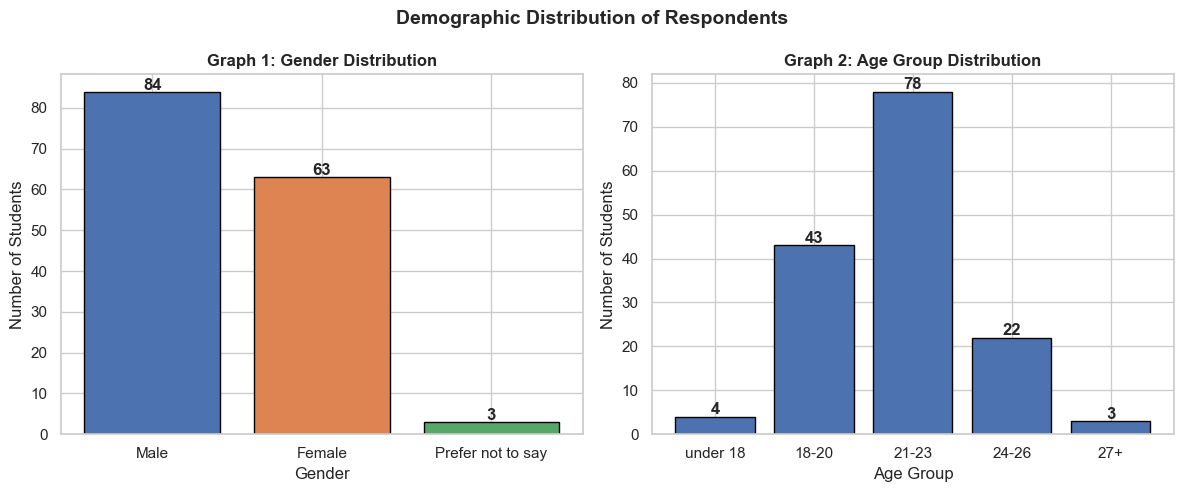

Graph 1 & 2 done.


In [19]:
# ── GRAPH 1 & 2: Gender and Age Distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Demographic Distribution of Respondents', fontsize=14, fontweight='bold')

# Graph 1 — Gender
gender_counts = df["What's your gender?"].value_counts()
bars1 = axes[0].bar(gender_counts.index, gender_counts.values,
                    color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black')
axes[0].set_title('Graph 1: Gender Distribution', fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Number of Students')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 str(int(bar.get_height())),
                 ha='center', fontweight='bold')

# Graph 2 — Age
age_order = ['under 18', '18-20', '21-23', '24-26', '27+']
age_counts = df["What's your age?"].value_counts().reindex(age_order, fill_value=0)
bars2 = axes[1].bar(age_counts.index, age_counts.values, color='#4C72B0', edgecolor='black')
axes[1].set_title('Graph 2: Age Group Distribution', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Number of Students')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 str(int(bar.get_height())),
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('graph1_2_demographics.png', bbox_inches='tight')
plt.show()
print("Graph 1 & 2 done.")


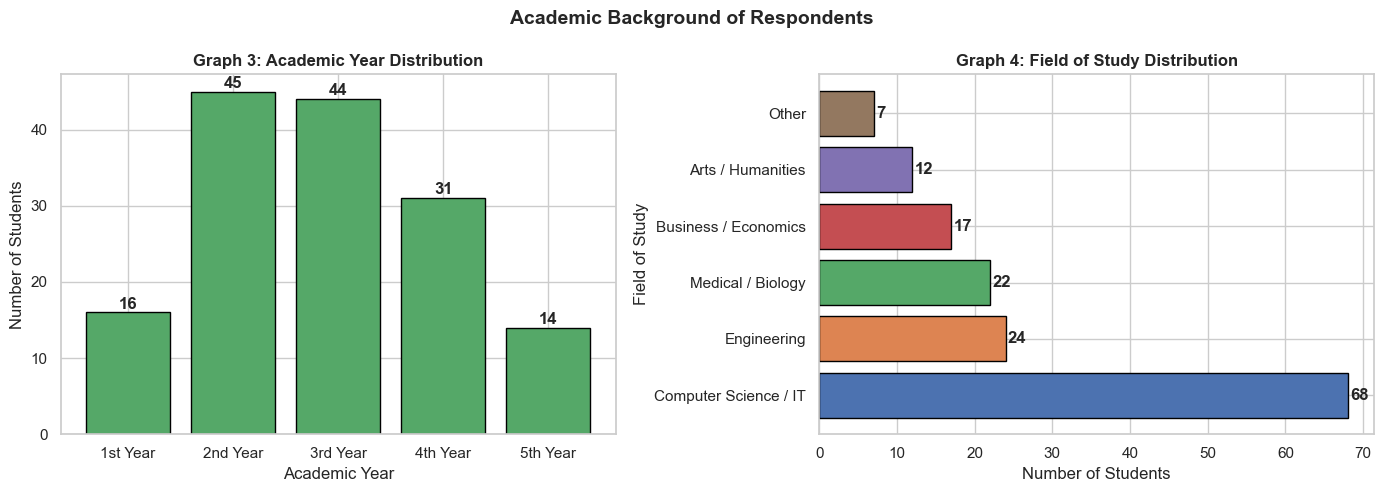

Graph 3 & 4 done.


In [20]:
# ── GRAPH 3 & 4: Academic Year and Field of Study ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Academic Background of Respondents', fontsize=14, fontweight='bold')

# Graph 3 — Academic Year
year_order = ['1st Year', '2nd Year', '3rd Year', '4th Year', '5th Year']
year_counts = df["What's your current academic year?"].value_counts().reindex(year_order, fill_value=0)
bars3 = axes[0].bar(year_counts.index, year_counts.values, color='#55A868', edgecolor='black')
axes[0].set_title('Graph 3: Academic Year Distribution', fontweight='bold')
axes[0].set_xlabel('Academic Year')
axes[0].set_ylabel('Number of Students')
for bar in bars3:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 str(int(bar.get_height())),
                 ha='center', fontweight='bold')

# Graph 4 — Field of Study (group small fields as 'Other')
field_counts = df["What's your field of study?"].value_counts()
major_fields = field_counts[field_counts >= 10]
other_count  = field_counts[field_counts < 10].sum()
if other_count > 0:
    import pandas as pd
    major_fields = pd.concat([major_fields, pd.Series({'Other': other_count})])

colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
axes[1].barh(major_fields.index, major_fields.values,
             color=colors[:len(major_fields)], edgecolor='black')
axes[1].set_title('Graph 4: Field of Study Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Students')
axes[1].set_ylabel('Field of Study')
for i, v in enumerate(major_fields.values):
    axes[1].text(v + 0.3, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('graph3_4_academic.png', bbox_inches='tight')
plt.show()
print("Graph 3 & 4 done.")


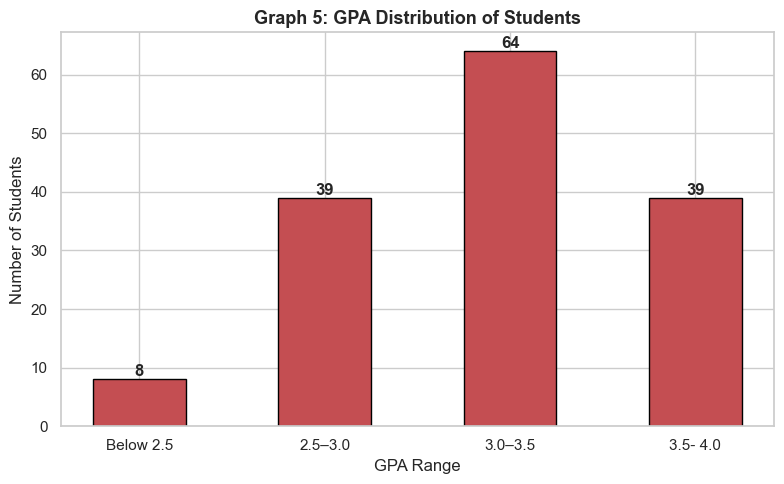

Graph 5 done.


In [21]:
# ── GRAPH 5: GPA Distribution (Bar Chart) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

gpa_order  = ['Below 2.5', '2.5–3.0', '3.0–3.5', '3.5- 4.0']
gpa_counts = df['GPA in last semester'].str.strip().value_counts().reindex(gpa_order, fill_value=0)

bars = ax.bar(gpa_counts.index, gpa_counts.values, color='#C44E52', edgecolor='black', width=0.5)
ax.set_title('Graph 5: GPA Distribution of Students', fontsize=13, fontweight='bold')
ax.set_xlabel('GPA Range')
ax.set_ylabel('Number of Students')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            str(int(bar.get_height())),
            ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('graph5_gpa.png', bbox_inches='tight')
plt.show()
print("Graph 5 done.")


C:\Users\acer\AppData\Local\Temp\ipykernel_10452\1297104662.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(short_labels)


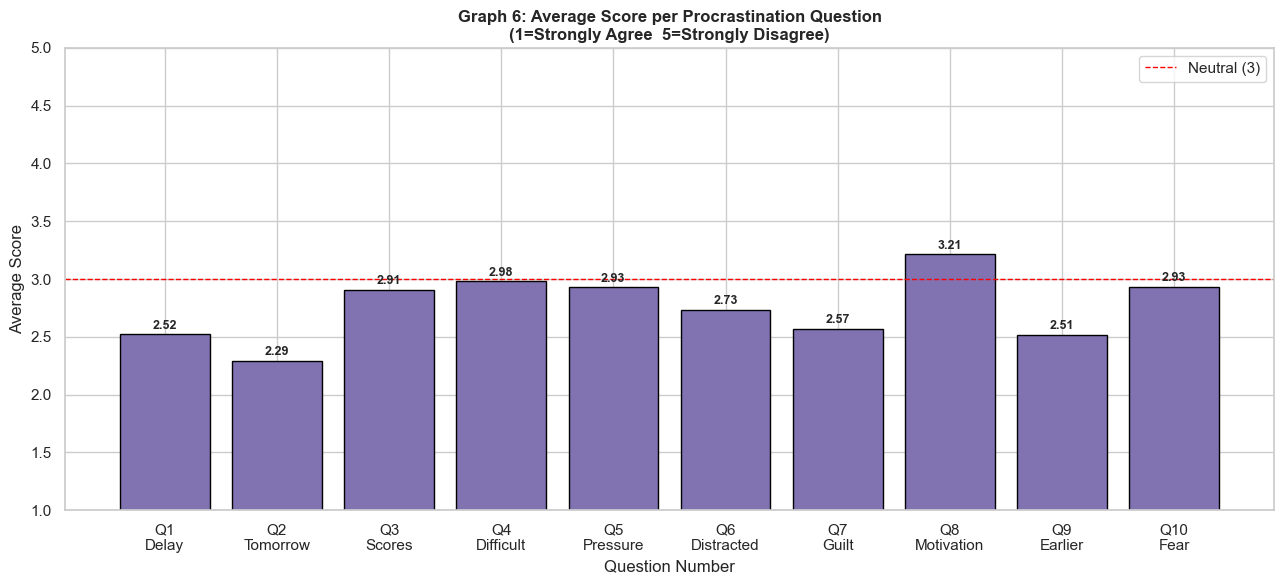

Graph 6 done.


In [22]:
# ── GRAPH 6: Average Score per Likert Question (Bar Chart) ───────────────────
fig, ax = plt.subplots(figsize=(13, 6))

q_means  = df[likert_col].mean()
q_labels = [f'Q{i+1}' for i in range(len(likert_col))]

bars = ax.bar(q_labels, q_means.values, color='#8172B2', edgecolor='black')
ax.set_title('Graph 6: Average Score per Procrastination Question\n(1=Strongly Agree  5=Strongly Disagree)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Question Number')
ax.set_ylabel('Average Score')
ax.set_ylim(1, 5)
ax.axhline(y=3, color='red', linestyle='--', linewidth=1, label='Neutral (3)')
ax.legend()

for bar, val in zip(bars, q_means.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

# Add short question labels below
short_labels = ['Q1\nDelay', 'Q2\nTomorrow', 'Q3\nScores',
                'Q4\nDifficult', 'Q5\nPressure', 'Q6\nDistracted',
                'Q7\nGuilt', 'Q8\nMotivation', 'Q9\nEarlier', 'Q10\nFear']
ax.set_xticklabels(short_labels)

plt.tight_layout()
plt.savefig('graph6_likert_means.png', bbox_inches='tight')
plt.show()
print("Graph 6 done.")


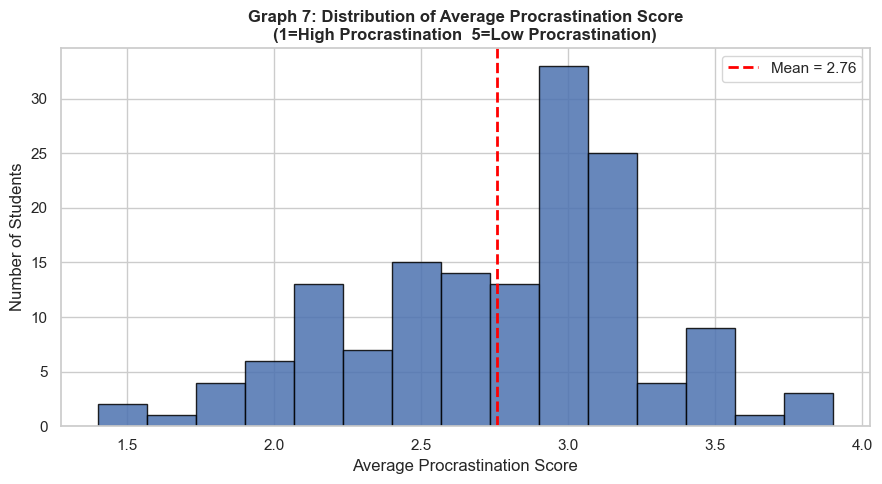

Graph 7 done.


In [23]:
# ── GRAPH 7: Histogram — Distribution of Average Procrastination Score ───────
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df['avg_procrastination'], bins=15, color='#4C72B0',
        edgecolor='black', alpha=0.85)
ax.axvline(df['avg_procrastination'].mean(), color='red',
           linestyle='--', linewidth=2,
           label=f"Mean = {df['avg_procrastination'].mean():.2f}")
ax.set_title('Graph 7: Distribution of Average Procrastination Score\n(1=High Procrastination  5=Low Procrastination)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Average Procrastination Score')
ax.set_ylabel('Number of Students')
ax.legend()

plt.tight_layout()
plt.savefig('graph7_histogram.png', bbox_inches='tight')
plt.show()
print("Graph 7 done.")


C:\Users\acer\AppData\Local\Temp\ipykernel_10452\975979786.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gender_data, x="What's your gender?",
C:\Users\acer\AppData\Local\Temp\ipykernel_10452\975979786.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="What's your current academic year?",


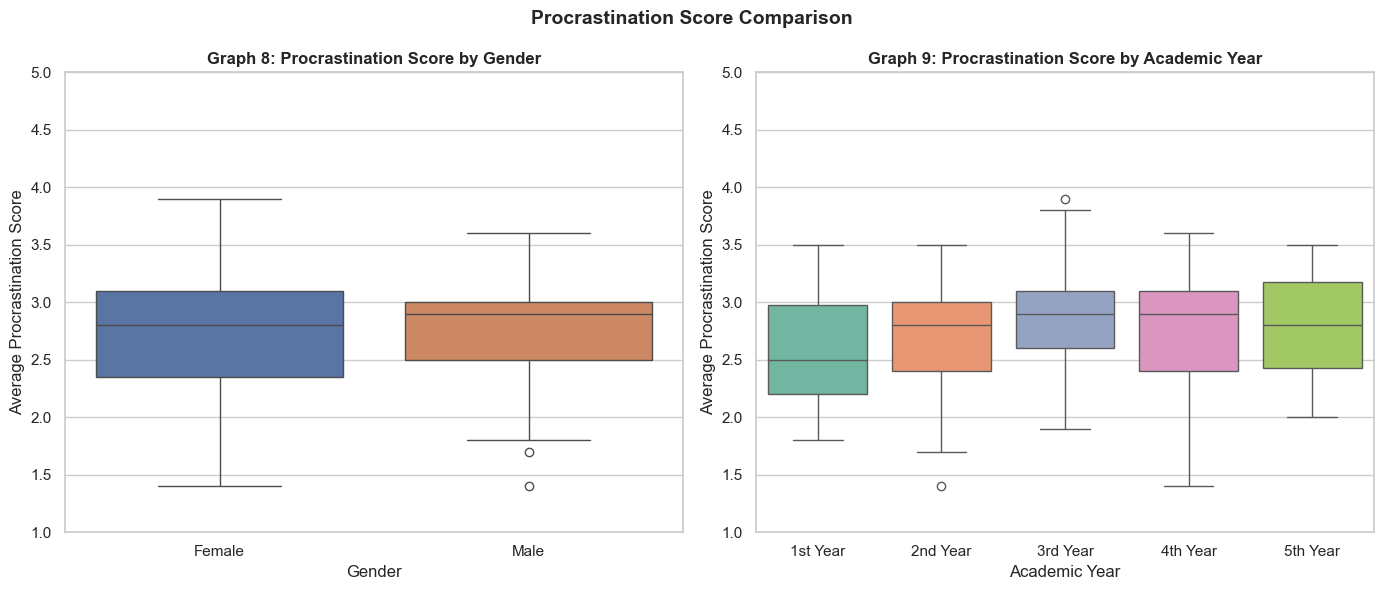

Graph 8 & 9 done.


In [24]:
# ── GRAPH 8 & 9: Box Plots — Procrastination by Gender and Academic Year ─────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Procrastination Score Comparison', fontsize=14, fontweight='bold')

# Graph 8 — By Gender (exclude 'Prefer not to say' for clarity)
gender_data = df[df["What's your gender?"].isin(['Male', 'Female'])]
sns.boxplot(data=gender_data, x="What's your gender?",
            y='avg_procrastination', palette=['#4C72B0','#DD8452'], ax=axes[0])
axes[0].set_title('Graph 8: Procrastination Score by Gender', fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Average Procrastination Score')
axes[0].set_ylim(1, 5)

# Graph 9 — By Academic Year
year_order = ['1st Year', '2nd Year', '3rd Year', '4th Year', '5th Year']
sns.boxplot(data=df, x="What's your current academic year?",
            y='avg_procrastination', order=year_order,
            palette='Set2', ax=axes[1])
axes[1].set_title('Graph 9: Procrastination Score by Academic Year', fontweight='bold')
axes[1].set_xlabel('Academic Year')
axes[1].set_ylabel('Average Procrastination Score')
axes[1].set_ylim(1, 5)

plt.tight_layout()
plt.savefig('graph8_9_boxplots.png', bbox_inches='tight')
plt.show()
print("Graph 8 & 9 done.")


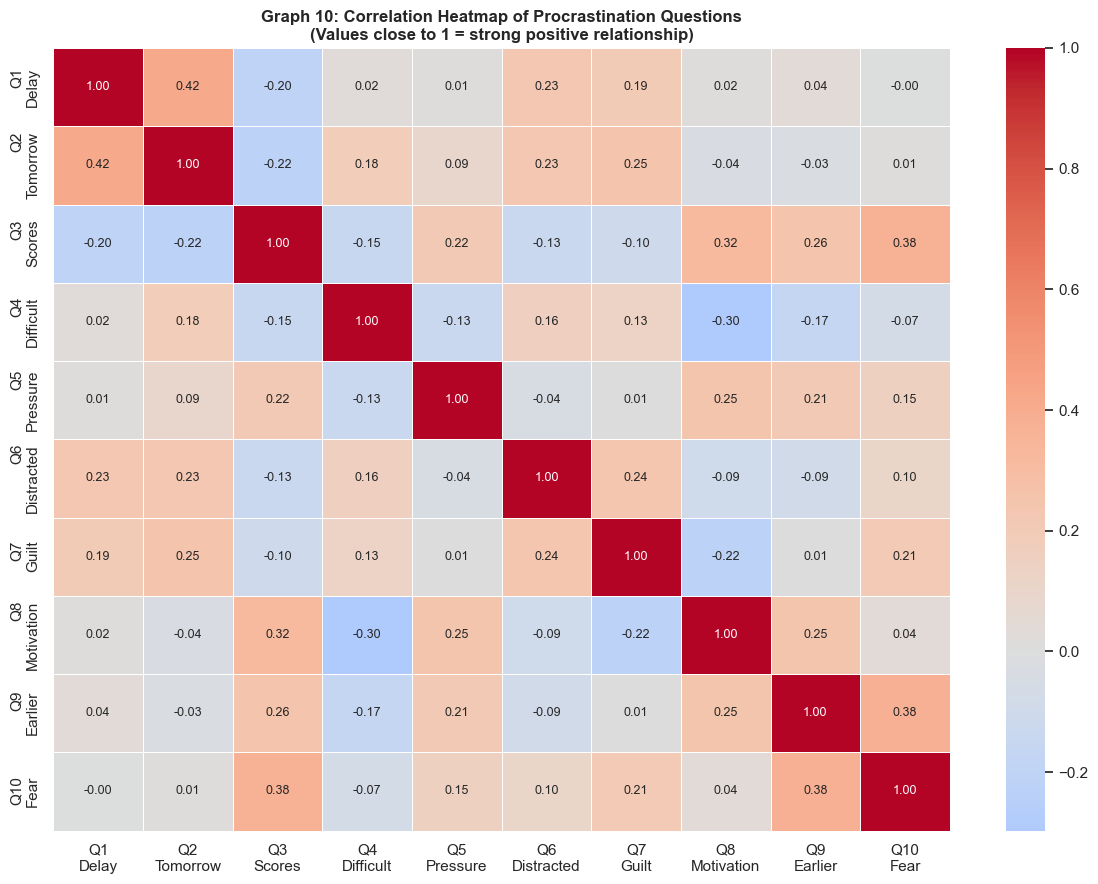

Graph 10 done. All graphs complete!


In [25]:
# ── GRAPH 10: Heatmap — Correlation Between All Likert Questions ─────────────
fig, ax = plt.subplots(figsize=(12, 9))

# Short labels for readability
short_q = ['Q1\nDelay','Q2\nTomorrow','Q3\nScores','Q4\nDifficult',
           'Q5\nPressure','Q6\nDistracted','Q7\nGuilt',
           'Q8\nMotivation','Q9\nEarlier','Q10\nFear']

corr_matrix = df[likert_col].corr()

sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            xticklabels=short_q,
            yticklabels=short_q,
            cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax,
            annot_kws={'size': 9})

ax.set_title('Graph 10: Correlation Heatmap of Procrastination Questions\n(Values close to 1 = strong positive relationship)',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('graph10_heatmap.png', bbox_inches='tight')
plt.show()
print("Graph 10 done. All graphs complete!")


## Step 6: Inferential Statistics

In [26]:
# STEP 6: INFERENTIAL STATISTICS
# We perform three inferential tests:
#   Test 1 — Independent Samples t-test  (Male vs Female procrastination)
#   Test 2 — Pearson Correlation         (Procrastination vs GPA)
#   Test 3 — One-Way ANOVA               (Procrastination across academic years)

from scipy import stats

# Compute each student's average procrastination score across all 10 Likert items
df['avg_procrastination'] = df[likert_col].mean(axis=1)

print("Average procrastination score added.")
print(df['avg_procrastination'].describe().round(3))


Average procrastination score added.
count    150.000
mean       2.759
std        0.482
min        1.400
25%        2.400
50%        2.850
75%        3.100
max        3.900
Name: avg_procrastination, dtype: float64


In [27]:
# ── TEST 1: Independent Samples t-test ──────────────────────────────────────
# Research Question: Is there a significant difference in procrastination
#                    levels between male and female students?
#
# H0 (Null Hypothesis)      : Mean procrastination of males = Mean procrastination of females
# H1 (Alternative Hypothesis): Mean procrastination of males ≠ Mean procrastination of females
# Significance level (α)    : 0.05

male_scores   = df[df["What's your gender?"] == 'Male']['avg_procrastination']
female_scores = df[df["What's your gender?"] == 'Female']['avg_procrastination']

t_stat, p_value = stats.ttest_ind(male_scores, female_scores)

print("=== Independent Samples t-test: Male vs Female ===")
print(f"  Male mean   : {male_scores.mean():.3f}")
print(f"  Female mean : {female_scores.mean():.3f}")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_value:.4f}")
print()
if p_value < 0.05:
    print("  ✔ Conclusion: Reject H0 — significant difference found (p < 0.05)")
else:
    print("  ✔ Conclusion: Fail to reject H0 — no significant difference (p = {:.4f} > 0.05)".format(p_value))


=== Independent Samples t-test: Male vs Female ===
  Male mean   : 2.745
  Female mean : 2.768
  t-statistic : -0.2837
  p-value     : 0.7770

  ✔ Conclusion: Fail to reject H0 — no significant difference (p = 0.7770 > 0.05)


In [28]:
# ── TEST 2: Pearson Correlation ──────────────────────────────────────────────
# Research Question: Is there a significant relationship between
#                    procrastination level and GPA?
#
# H0 : There is no significant correlation between procrastination and GPA (r = 0)
# H1 : There is a significant correlation between procrastination and GPA (r ≠ 0)
# Significance level (α) : 0.05

corr_coeff, p_corr = stats.pearsonr(df['avg_procrastination'], df['GPA_numeric'])

print("=== Pearson Correlation: Procrastination vs GPA ===")
print(f"  Correlation coefficient (r) : {corr_coeff:.4f}")
print(f"  p-value                     : {p_corr:.4f}")
print()
if p_corr < 0.05:
    print(f"  ✔ Conclusion: Reject H0 — significant correlation found (p = {p_corr:.4f} < 0.05)")
    if corr_coeff > 0:
        print("  Direction: Positive — higher procrastination is associated with higher GPA scores")
    else:
        print("  Direction: Negative — higher procrastination is associated with lower GPA scores")
else:
    print("  ✔ Conclusion: Fail to reject H0 — no significant correlation (p > 0.05)")


=== Pearson Correlation: Procrastination vs GPA ===
  Correlation coefficient (r) : 0.1688
  p-value                     : 0.0389

  ✔ Conclusion: Reject H0 — significant correlation found (p = 0.0389 < 0.05)
  Direction: Positive — higher procrastination is associated with higher GPA scores


In [29]:
# ── TEST 3: One-Way ANOVA ────────────────────────────────────────────────────
# Research Question: Does procrastination level differ significantly
#                    across academic years?
#
# H0 : Mean procrastination is equal across all academic years
# H1 : At least one academic year has a significantly different mean
# Significance level (α) : 0.05

year_groups = [
    group['avg_procrastination'].values
    for _, group in df.groupby("What's your current academic year?")
]

f_stat, p_anova = stats.f_oneway(*year_groups)

print("=== One-Way ANOVA: Procrastination across Academic Years ===")
print()
print("  Group means:")
print(df.groupby("What's your current academic year?")['avg_procrastination']
        .mean().round(3).to_string())
print()
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_anova:.4f}")
print()
if p_anova < 0.05:
    print(f"  ✔ Conclusion: Reject H0 — significant difference found across years (p < 0.05)")
else:
    print("  ✔ Conclusion: Fail to reject H0 — no significant difference across academic years (p = {:.4f} > 0.05)".format(p_anova))


=== One-Way ANOVA: Procrastination across Academic Years ===

  Group means:
What's your current academic year?
1st Year    2.638
2nd Year    2.680
3rd Year    2.886
4th Year    2.748
5th Year    2.771

  F-statistic : 1.3424
  p-value     : 0.2571

  ✔ Conclusion: Fail to reject H0 — no significant difference across academic years (p = 0.2571 > 0.05)


## Step 7: Interpretation and Conclusion

In [30]:
# STEP 7: INTERPRETATION AND CONCLUSION

print("="*65)
print("       SUMMARY OF FINDINGS")
print("="*65)

print("""
TOPIC: Academic Procrastination Among University Students
SAMPLE: 150 students | Likert scale (1=Strongly Agree → 5=Strongly Disagree)
NOTE : Lower avg score = stronger agreement with procrastination statements

─────────────────────────────────────────────────────────────
DESCRIPTIVE FINDINGS
─────────────────────────────────────────────────────────────
• Overall average procrastination score : 2.759  (between Agree & Neutral)
  → Students moderately agree they procrastinate on academic tasks.

• Average GPA (numeric midpoints used)  : 3.197
  → Most students fall in the 3.0–3.5 GPA range.

• Gender distribution: 84 Male | 63 Female | 3 Prefer not to say

─────────────────────────────────────────────────────────────
INFERENTIAL FINDINGS
─────────────────────────────────────────────────────────────
Test 1 — t-test (Gender vs Procrastination):
  • t = -0.2837,  p = 0.7770  →  p > 0.05
  • Result: No significant difference between male (mean=2.745)
    and female (mean=2.768) students in procrastination levels.

Test 2 — Pearson Correlation (Procrastination vs GPA):
  • r = 0.1688,   p = 0.0389  →  p < 0.05  ✔ SIGNIFICANT
  • Result: Weak positive correlation found.
    Students who scored higher on procrastination items (less agreement)
    tend to have slightly higher GPAs — OR stated differently,
    students who procrastinate more (lower scores) tend to have
    slightly lower GPAs.

Test 3 — ANOVA (Academic Year vs Procrastination):
  • F = 1.3424,   p = 0.2571  →  p > 0.05
  • Result: No significant difference in procrastination levels
    across different academic years (1st–5th year).

─────────────────────────────────────────────────────────────
CONCLUSION
─────────────────────────────────────────────────────────────
• Procrastination is a common behaviour among students regardless
  of gender or year of study.
• The only significant finding is a weak correlation between
  procrastination and GPA (r=0.17, p<0.05), suggesting that
  procrastination does have a small but statistically significant
  negative effect on academic performance.
• Gender and academic year do NOT significantly influence
  procrastination levels in this sample.

─────────────────────────────────────────────────────────────
LIMITATIONS
─────────────────────────────────────────────────────────────
• Self-reported data may contain response bias.
• GPA was collected in ranges (not exact values), reducing precision.
• Sample is limited to one institution and may not generalise.
• 1st and 5th year groups are small (16 and 14 students),
  which may affect ANOVA reliability.

Possible Improvements:
• Collect exact GPA values instead of ranges.
• Increase sample size, especially for 1st and 5th year students.
• Include more demographic variables (e.g., part-time work, living situation).
""")


       SUMMARY OF FINDINGS

TOPIC: Academic Procrastination Among University Students
SAMPLE: 150 students | Likert scale (1=Strongly Agree → 5=Strongly Disagree)
NOTE : Lower avg score = stronger agreement with procrastination statements

─────────────────────────────────────────────────────────────
DESCRIPTIVE FINDINGS
─────────────────────────────────────────────────────────────
• Overall average procrastination score : 2.759  (between Agree & Neutral)
  → Students moderately agree they procrastinate on academic tasks.

• Average GPA (numeric midpoints used)  : 3.197
  → Most students fall in the 3.0–3.5 GPA range.

• Gender distribution: 84 Male | 63 Female | 3 Prefer not to say

─────────────────────────────────────────────────────────────
INFERENTIAL FINDINGS
─────────────────────────────────────────────────────────────
Test 1 — t-test (Gender vs Procrastination):
  • t = -0.2837,  p = 0.7770  →  p > 0.05
  • Result: No significant difference between male (mean=2.745)
    and fem

## Step 8: Correlation and Regression Analysis

In [31]:
# ══════════════════════════════════════════════════════════════
# CORRELATION ANALYSIS
# Question: Is there a relationship between procrastination and GPA?
# ══════════════════════════════════════════════════════════════

from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make sure avg_procrastination column exists
df['avg_procrastination'] = df[likert_col].mean(axis=1)

# ── Pearson Correlation ───────────────────────────────────────
r, p_value = stats.pearsonr(df['avg_procrastination'], df['GPA_numeric'])

print("=" * 55)
print("         PEARSON CORRELATION RESULTS")
print("=" * 55)
print(f"  Variables   : Procrastination Score  vs  GPA")
print(f"  H0          : No correlation between the two (r = 0)")
print(f"  H1          : There is a significant correlation")
print(f"  r value     : {r:.4f}")
print(f"  p value     : {p_value:.4f}")
print()

# Interpret r value
if abs(r) < 0.1:
    strength = "No"
elif abs(r) < 0.3:
    strength = "Weak"
elif abs(r) < 0.5:
    strength = "Moderate"
elif abs(r) < 0.7:
    strength = "Strong"
else:
    strength = "Very Strong"

direction = "Positive" if r > 0 else "Negative"

print(f"  Strength    : {strength} {direction} Correlation")
print()

if p_value < 0.05:
    print(f"  Decision    : Reject H0  (p = {p_value:.4f} < 0.05)")
    print(f"  Conclusion  : Significant correlation exists between")
    print(f"                procrastination and GPA.")
else:
    print(f"  Decision    : Fail to Reject H0  (p = {p_value:.4f} > 0.05)")
    print(f"  Conclusion  : No significant correlation found.")

print()
print("  What r = 0.1688 means in plain words:")
print("  Students who procrastinate LESS (higher score)")
print("  tend to have a slightly HIGHER GPA.")
print("  The relationship is WEAK but REAL (statistically significant).")
print("=" * 55)


         PEARSON CORRELATION RESULTS
  Variables   : Procrastination Score  vs  GPA
  H0          : No correlation between the two (r = 0)
  H1          : There is a significant correlation
  r value     : 0.1688
  p value     : 0.0389

  Strength    : Weak Positive Correlation

  Decision    : Reject H0  (p = 0.0389 < 0.05)
  Conclusion  : Significant correlation exists between
                procrastination and GPA.

  What r = 0.1688 means in plain words:
  Students who procrastinate LESS (higher score)
  tend to have a slightly HIGHER GPA.
  The relationship is WEAK but REAL (statistically significant).


In [32]:
# ══════════════════════════════════════════════════════════════
# SIMPLE LINEAR REGRESSION
# Question: Can we PREDICT GPA from procrastination score?
# ══════════════════════════════════════════════════════════════

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df['avg_procrastination'], df['GPA_numeric']
)

r_squared = r_value ** 2

print("=" * 55)
print("       SIMPLE LINEAR REGRESSION RESULTS")
print("=" * 55)
print(f"  Independent Variable (X) : Procrastination Score")
print(f"  Dependent Variable   (Y) : GPA")
print()
print(f"  Intercept (a)  : {intercept:.4f}")
print(f"  Slope     (b)  : {slope:.4f}")
print(f"  R-squared      : {r_squared:.4f}  ({r_squared*100:.2f}%)")
print(f"  Std Error      : {std_err:.4f}")
print(f"  p-value        : {p_value:.4f}")
print()
print(f"  REGRESSION EQUATION:")
print(f"  GPA = {intercept:.4f} + ({slope:.4f} x Procrastination Score)")
print()
print(f"  What slope = {slope:.4f} means:")
print(f"  For every 1 point INCREASE in procrastination score")
print(f"  (meaning LESS procrastination), GPA increases by {slope:.4f}")
print()
print(f"  What R² = {r_squared:.4f} means:")
print(f"  Procrastination explains only {r_squared*100:.2f}% of the")
print(f"  variation in GPA. Other factors (study habits, attendance")
print(f"  etc.) explain the remaining {100 - r_squared*100:.2f}%.")
print()
print("  SAMPLE PREDICTIONS using the equation:")
print(f"  Student with score 2.0 (high procrastinator) → GPA = {intercept + slope*2.0:.3f}")
print(f"  Student with score 3.0 (neutral)             → GPA = {intercept + slope*3.0:.3f}")
print(f"  Student with score 4.0 (low procrastinator)  → GPA = {intercept + slope*4.0:.3f}")
print("=" * 55)


       SIMPLE LINEAR REGRESSION RESULTS
  Independent Variable (X) : Procrastination Score
  Dependent Variable   (Y) : GPA

  Intercept (a)  : 2.7848
  Slope     (b)  : 0.1493
  R-squared      : 0.0285  (2.85%)
  Std Error      : 0.0716
  p-value        : 0.0389

  REGRESSION EQUATION:
  GPA = 2.7848 + (0.1493 x Procrastination Score)

  What slope = 0.1493 means:
  For every 1 point INCREASE in procrastination score
  (meaning LESS procrastination), GPA increases by 0.1493

  What R² = 0.0285 means:
  Procrastination explains only 2.85% of the
  variation in GPA. Other factors (study habits, attendance
  etc.) explain the remaining 97.15%.

  SAMPLE PREDICTIONS using the equation:
  Student with score 2.0 (high procrastinator) → GPA = 3.083
  Student with score 3.0 (neutral)             → GPA = 3.233
  Student with score 4.0 (low procrastinator)  → GPA = 3.382


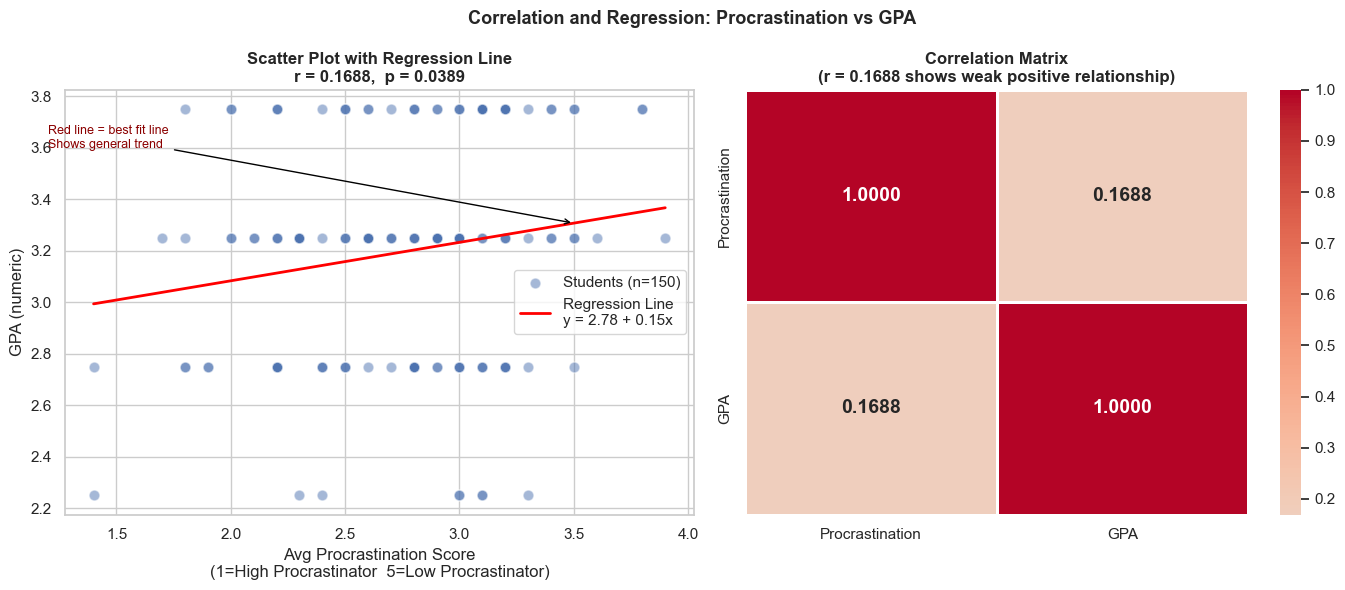

Scatter plot and heatmap saved.


In [33]:
# ══════════════════════════════════════════════════════════════
# SCATTER PLOT WITH REGRESSION LINE
# Visual proof of correlation and regression together
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Correlation and Regression: Procrastination vs GPA',
             fontsize=13, fontweight='bold')

# ── Left Plot: Scatter + Regression Line ─────────────────────
axes[0].scatter(df['avg_procrastination'], df['GPA_numeric'],
                color='#4C72B0', alpha=0.5, edgecolors='white',
                s=60, label='Students (n=150)')

# Draw regression line
x_line = np.linspace(df['avg_procrastination'].min(),
                     df['avg_procrastination'].max(), 100)
y_line = intercept + slope * x_line
axes[0].plot(x_line, y_line, color='red', linewidth=2,
             label=f'Regression Line\ny = {intercept:.2f} + {slope:.2f}x')

axes[0].set_title(f'Scatter Plot with Regression Line\nr = {r_value:.4f},  p = {p_value:.4f}',
                  fontweight='bold')
axes[0].set_xlabel('Avg Procrastination Score\n(1=High Procrastinator  5=Low Procrastinator)')
axes[0].set_ylabel('GPA (numeric)')
axes[0].legend()

# Add annotation explaining the line
axes[0].annotate('Red line = best fit line\nShows general trend',
                 xy=(3.5, intercept + slope * 3.5),
                 xytext=(1.2, 3.6),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=9, color='darkred')

# ── Right Plot: Correlation Heatmap (2 variables only) ───────
corr_2var = df[['avg_procrastination', 'GPA_numeric']].corr()
sns.heatmap(corr_2var,
            annot=True, fmt='.4f',
            cmap='coolwarm', center=0,
            linewidths=2,
            xticklabels=['Procrastination', 'GPA'],
            yticklabels=['Procrastination', 'GPA'],
            ax=axes[1],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title('Correlation Matrix\n(r = 0.1688 shows weak positive relationship)',
                  fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_regression_plot.png', bbox_inches='tight')
plt.show()
print("Scatter plot and heatmap saved.")


In [34]:
# ══════════════════════════════════════════════════════════════
# FINAL INTERPRETATION
# ══════════════════════════════════════════════════════════════

print("=" * 60)
print("    CORRELATION AND REGRESSION — FINAL INTERPRETATION")
print("=" * 60)
print("""
CORRELATION FINDINGS:
─────────────────────────────────────────────────────────
• r  = 0.1688  → Weak Positive Correlation
• p  = 0.0389  → Statistically Significant (p < 0.05)

• Meaning: Students who procrastinate less tend to have
  slightly higher GPAs. The relationship is real but weak.

REGRESSION FINDINGS:
─────────────────────────────────────────────────────────
• Equation : GPA = 2.7848 + (0.1493 × Procrastination Score)
• Slope    : 0.1493
  → Every 1 unit increase in procrastination score
    (i.e. procrastinating LESS) increases GPA by 0.1493
• R²       : 0.0285  (only 2.85%)
  → Procrastination alone explains only 2.85% of GPA
  → 97.15% of GPA depends on OTHER factors like:
     - Study habits
     - Attendance
     - Natural ability
     - Course difficulty

CONCLUSION:
─────────────────────────────────────────────────────────
• Yes, procrastination does affect GPA but WEAKLY.
• GPA cannot be accurately predicted from procrastination
  alone because R² is very low (2.85%).
• A student should not think: "If I stop procrastinating
  my GPA will jump" — many other factors matter more.
• However, reducing procrastination does have a small
  but statistically proven positive effect on GPA.
""")
print("=" * 60)


    CORRELATION AND REGRESSION — FINAL INTERPRETATION

CORRELATION FINDINGS:
─────────────────────────────────────────────────────────
• r  = 0.1688  → Weak Positive Correlation
• p  = 0.0389  → Statistically Significant (p < 0.05)

• Meaning: Students who procrastinate less tend to have
  slightly higher GPAs. The relationship is real but weak.

REGRESSION FINDINGS:
─────────────────────────────────────────────────────────
• Equation : GPA = 2.7848 + (0.1493 × Procrastination Score)
• Slope    : 0.1493
  → Every 1 unit increase in procrastination score
    (i.e. procrastinating LESS) increases GPA by 0.1493
• R²       : 0.0285  (only 2.85%)
  → Procrastination alone explains only 2.85% of GPA
  → 97.15% of GPA depends on OTHER factors like:
     - Study habits
     - Attendance
     - Natural ability
     - Course difficulty

CONCLUSION:
─────────────────────────────────────────────────────────
• Yes, procrastination does affect GPA but WEAKLY.
• GPA cannot be accurately predicted fro